# Phase 7 — Explainability Analysis (Grad-CAM)

Produces Grad-CAM-style heatmaps for Good / Bad / Failure predictions from both detectors to assess whether each model attends to the tumor region or to background/skull structures.

Assumes `model_yolo`, `model_frcnn`, `device`, `box_iou_np`, and the predict wrappers from notebook 04 are available in the session.

In [14]:
!git clone https://github.com/javidfarsoft-bot/brain-tumor-detection-comparison.git
%cd brain-tumor-detection-comparison
!pip install kaggle pycocotools ultralytics torchmetrics grad-cam -q

Cloning into 'brain-tumor-detection-comparison'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 183 (delta 7), reused 0 (delta 0), pack-reused 167 (from 1)
Receiving objects: 100% (183/183), 17.86 MiB | 13.25 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/content/brain-tumor-detection-comparison
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.2 MB/s eta 0:00:00


In [15]:
!mkdir -p ~/.kaggle
!echo YOUR_KAGGLE_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!kaggle datasets download -d ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
!mkdir -p data/raw
!unzip -q -o mri-for-brain-tumor-with-bounding-boxes.zip -d data/raw
!python -m src.data.merge_dataset --src data/raw --dst data/yolo

Dataset URL: https://www.kaggle.com/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
License(s): CC0-1.0
100% 133M/133M [00:04<00:00, 30.7MB/s]

Total images found: 5247
Train: 4197  Valid: 522  Test: 528
Done.


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import torch, os
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms.functional as F
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

model_yolo = YOLO("outputs/weights/yolo_best.pt")

num_classes = len(class_names) + 1
model_frcnn = fasterrcnn_resnet50_fpn_v2(weights=None)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
ckpt = torch.load("/content/drive/MyDrive/brain-tumor-project/checkpoints/fasterrcnn_best.pth", map_location=device)
model_frcnn.load_state_dict(ckpt["model_state"])
model_frcnn.to(device).eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [18]:
def box_iou_np(box_a, box_b):
    x1 = max(box_a[0], box_b[0]); y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2]); y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def yolo_predict_fn(img_path):
    result = model_yolo.predict(img_path, conf=0.5, verbose=False)[0]
    return result.boxes.xyxy.cpu().numpy().tolist() if len(result.boxes) > 0 else []

def frcnn_predict_fn(img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        output = model_frcnn([img_tensor])[0]
    keep = output["scores"] >= 0.5
    return output["boxes"][keep].cpu().numpy().tolist()

In [19]:
!pip install grad-cam -q

In [20]:
import torch, os
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]

In [21]:
def box_iou_np(box_a, box_b):
    x1 = max(box_a[0], box_b[0]); y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2]); y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def yolo_predict_fn(img_path):
    result = model_yolo.predict(img_path, conf=0.5, verbose=False)[0]
    return result.boxes.xyxy.cpu().numpy().tolist() if len(result.boxes) > 0 else []

def frcnn_predict_fn(img_path):
    img = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(img).to(device)
    with torch.no_grad():
        output = model_frcnn([img_tensor])[0]
    keep = output["scores"] >= 0.5
    return output["boxes"][keep].cpu().numpy().tolist()

In [22]:
!pip install ultralytics -q
from ultralytics import YOLO

In [23]:
%cd /content/brain-tumor-detection-comparison
!ls

/content/brain-tumor-detection-comparison
01_dataset_exploration.ipynb		     notebooks	       results
configs					     outputs	       src
data					     README.md
mri-for-brain-tumor-with-bounding-boxes.zip  requirements.txt


In [24]:
from ultralytics import YOLO
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model_yolo = YOLO("outputs/weights/yolo_best.pt")

num_classes = len(class_names) + 1
model_frcnn = fasterrcnn_resnet50_fpn_v2(weights=None)
in_features = model_frcnn.roi_heads.box_predictor.cls_score.in_features
model_frcnn.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
ckpt = torch.load("/content/drive/MyDrive/brain-tumor-project/checkpoints/fasterrcnn_best.pth", map_location=device)
model_frcnn.load_state_dict(ckpt["model_state"])
model_frcnn.to(device).eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [25]:
import os, random
from PIL import Image

def classify_samples(predict_fn, images_dir, labels_dir, n_each=1):
    good, bad, failure = [], [], []
    img_files = list(os.listdir(images_dir))
    random.shuffle(img_files)
    for img_name in img_files:
        img_path = f"{images_dir}/{img_name}"
        lbl_path = f"{labels_dir}/{img_name.rsplit('.',1)[0]}.txt"
        img = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        if os.path.exists(lbl_path):
            for line in open(lbl_path).read().strip().splitlines():
                if not line: continue
                cls, xc, yc, bw, bh = map(float, line.split())
                x1, y1 = (xc-bw/2)*w, (yc-bh/2)*h
                x2, y2 = (xc+bw/2)*w, (yc+bh/2)*h
                gt_boxes.append([x1, y1, x2, y2])
        if not gt_boxes:
            continue
        pred_boxes = predict_fn(img_path)
        if not pred_boxes:
            if len(failure) < n_each:
                failure.append(img_path)
            continue
        best_iou = max(box_iou_np(pb, gt_boxes[0]) for pb in pred_boxes)
        if best_iou > 0.7 and len(good) < n_each:
            good.append(img_path)
        elif 0 < best_iou < 0.4 and len(bad) < n_each:
            bad.append(img_path)
        if len(good) >= n_each and len(bad) >= n_each and len(failure) >= n_each:
            break
    return {"good": good, "bad": bad, "failure": failure}

yolo_samples = classify_samples(yolo_predict_fn, "data/yolo/test/images", "data/yolo/test/labels")
frcnn_samples = classify_samples(frcnn_predict_fn, "data/yolo/test/images", "data/yolo/test/labels")
print("YOLO:", yolo_samples)
print("Faster R-CNN:", frcnn_samples)

YOLO: {'good': ['data/yolo/test/images/p (393).jpg'], 'bad': ['data/yolo/test/images/Tr-pi_0121.jpg'], 'failure': ['data/yolo/test/images/Tr-no_1310.jpg']}
Faster R-CNN: {'good': ['data/yolo/test/images/m3 (202).jpg'], 'bad': ['data/yolo/test/images/Tr-gl_0313.jpg'], 'failure': ['data/yolo/test/images/p (262).jpg']}


In [26]:
def find_lowest_confidence(images_dir, labels_dir, max_search=100):
    import torchvision.transforms.functional as F
    img_files = list(os.listdir(images_dir))
    random.shuffle(img_files)
    lowest_score, lowest_img = 1.0, None
    for img_name in img_files[:max_search]:
        img_path = f"{images_dir}/{img_name}"
        img = Image.open(img_path).convert("RGB")
        img_tensor = F.to_tensor(img).to(device)
        with torch.no_grad():
            output = model_frcnn([img_tensor])[0]
        if len(output["scores"]) > 0:
            max_score = output["scores"].max().item()
            if max_score < lowest_score:
                lowest_score, lowest_img = max_score, img_path
    return lowest_img, lowest_score

low_conf_img, low_conf_score = find_lowest_confidence("data/yolo/test/images", "data/yolo/test/labels")
frcnn_samples["failure"] = [low_conf_img]
print(f"Lowest confidence: {low_conf_score:.3f} on {low_conf_img}")

Lowest confidence: 0.353 on data/yolo/test/images/p (262).jpg


In [27]:
import cv2, numpy as np, torch
from pytorch_grad_cam.utils.image import show_cam_on_image

def yolo_eigencam_manual(img_path, model_yolo, device):
    target_layer = model_yolo.model.model[-2]
    activations = {}
    def hook(module, input, output):
        activations["value"] = output
    h = target_layer.register_forward_hook(hook)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (640, 640))
    rgb_img = img_resized.astype(np.float32) / 255.0
    input_tensor = torch.from_numpy(rgb_img).permute(2, 0, 1).unsqueeze(0).float().to(device)
    with torch.no_grad():
        model_yolo.model(input_tensor)
    h.remove()
    acts = activations["value"]
    if isinstance(acts, (list, tuple)):
        acts = acts[0]
    acts = acts[0].detach().cpu().numpy()
    reshaped = acts.reshape(acts.shape[0], -1).T
    reshaped = reshaped - reshaped.mean(axis=0)
    U, S, VT = np.linalg.svd(reshaped, full_matrices=False)
    cam = U[:, 0].reshape(acts.shape[1], acts.shape[2])
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (640, 640))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_image = show_cam_on_image(rgb_img, cam, use_rgb=True)
    return img_resized, cam_image

In [28]:
import torchvision.transforms.functional as F

def frcnn_gradcam(img_path, model_frcnn, device):
    img = Image.open(img_path).convert("RGB")
    img_resized = img.resize((512, 512))
    rgb_img = np.array(img_resized).astype(np.float32) / 255.0
    img_tensor = F.to_tensor(img_resized).to(device)
    target_layer = model_frcnn.backbone.body.layer4[-1]
    activations, gradients = {}, {}
    def forward_hook(module, input, output):
        activations["value"] = output
    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)
    img_tensor.requires_grad_(True)
    output = model_frcnn([img_tensor])[0]
    if len(output["scores"]) == 0:
        h1.remove(); h2.remove()
        return img_resized, np.array(img_resized)
    score = output["scores"].max()
    model_frcnn.zero_grad()
    score.backward()
    h1.remove(); h2.remove()
    acts = activations["value"][0].detach().cpu().numpy()
    grads = gradients["value"][0].detach().cpu().numpy()
    weights = grads.mean(axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w_ in enumerate(weights):
        cam += w_ * acts[i]
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (512, 512))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_image = show_cam_on_image(rgb_img, cam, use_rgb=True)
    return img_resized, cam_image

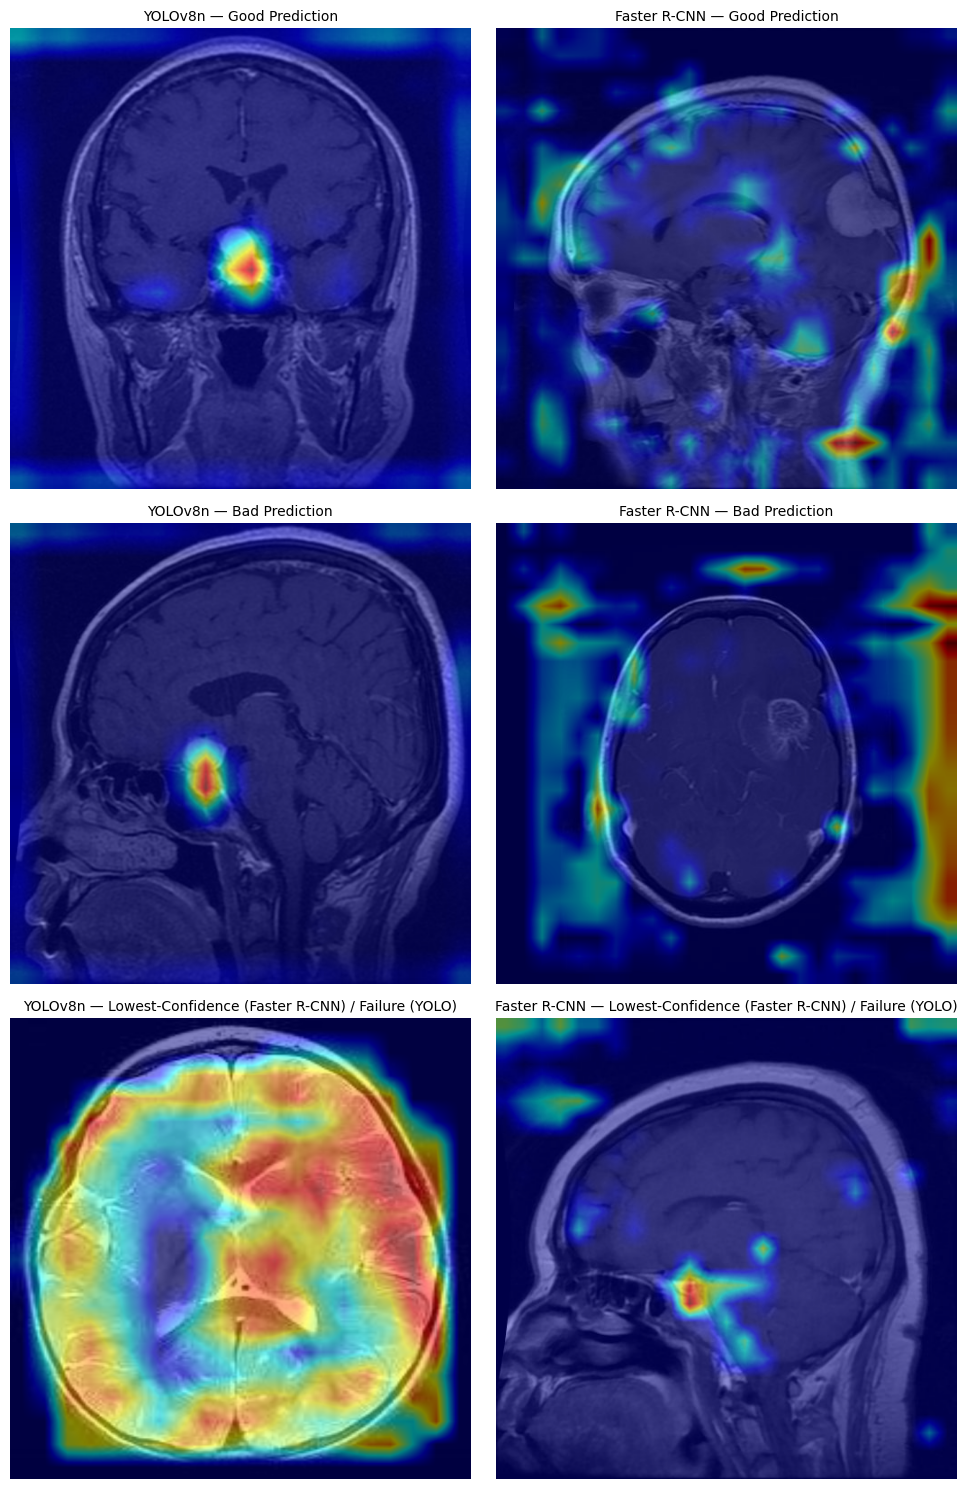

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
row_labels = ["Good Prediction", "Bad Prediction", "Lowest-Confidence (Faster R-CNN) / Failure (YOLO)"]
case_keys = ["good", "bad", "failure"]

for row, (case, label) in enumerate(zip(case_keys, row_labels)):
    yolo_img_path = yolo_samples[case][0]
    frcnn_img_path = frcnn_samples[case][0]
    _, yolo_cam = yolo_eigencam_manual(yolo_img_path, model_yolo, device)
    _, frcnn_cam = frcnn_gradcam(frcnn_img_path, model_frcnn, device)
    axes[row, 0].imshow(yolo_cam); axes[row, 0].set_title(f"YOLOv8n — {label}", fontsize=10); axes[row, 0].axis("off")
    axes[row, 1].imshow(frcnn_cam); axes[row, 1].set_title(f"Faster R-CNN — {label}", fontsize=10); axes[row, 1].axis("off")

plt.tight_layout()
import os
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/gradcam_comparison.png", dpi=150)
plt.show()

## Results

YOLOv8n produces a sharp, tumor-localized heatmap on confident correct
predictions and diffuse, unfocused activation on its failure cases (no
detection at all). Faster R-CNN's heatmaps tend to be more diffuse and mix
tumor-region with image-border activation (a partial artifact of zero-padding
in deep conv layers); it essentially never produces a complete detection
failure, though its lowest-confidence predictions can still activate
incorrect regions. Exact heatmap patterns vary between runs since sample
selection is randomized — see the current run's figure above and final
report Section 9 for a representative discussion.
